<a href="https://colab.research.google.com/github/OJB-Quantum/Generative-Layout-Notebooks/blob/main/Fibonacci_Fractal_Resonator_Coupled_to_Feedline_with_GDSTK_PHIDL_NetworkX_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install phidl gdstk networkx matplotlib numpy

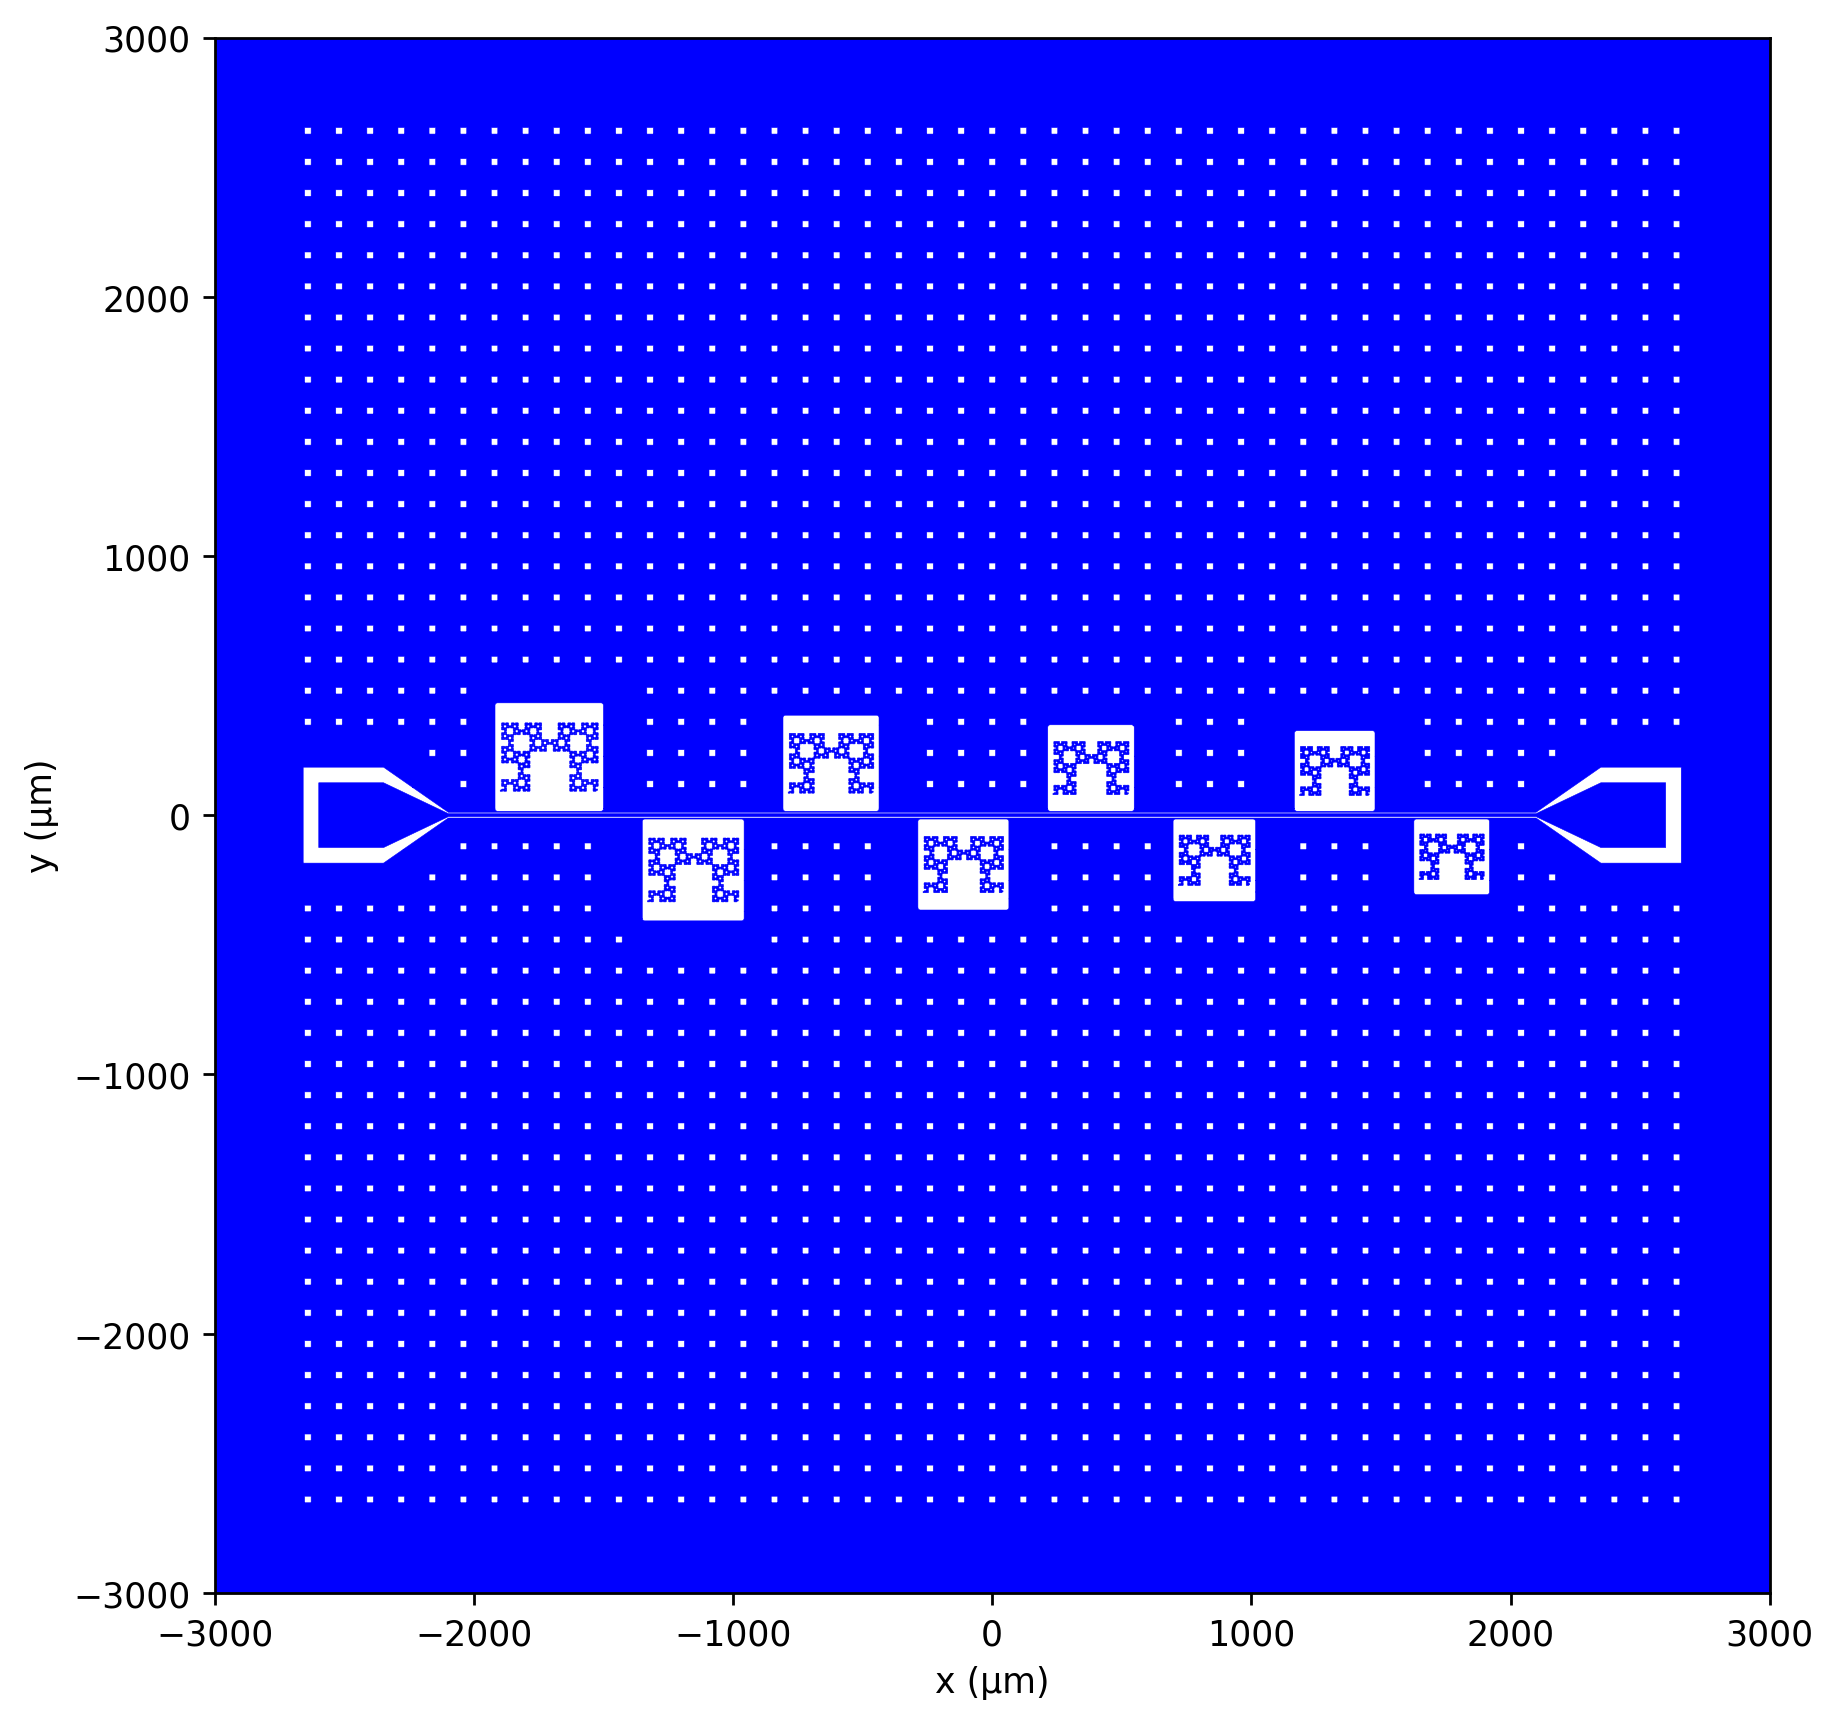

GDSTK version: 1.0.1
PHIDL version: 1.7.2
NetworkX version: 3.6.1
Generated resonators: 8
Generated feedlines: 1
Cheese holes: 1824
Chip size: 6000.000 µm × 6000.000 µm
In-memory polygon-buffer CRC32: 0xE685FAFC
OASIS written to: fibonacci_square_cavity_feedlines.oas


In [21]:
"""Generate a square-chip Fibonacci resonator and CPW feedline layout.

The layout places frequency-scaled Fibonacci-word resonators inside rounded square
pockets adjacent to one or more adaptive CPW feedlines. NetworkX defines straight
or serpentine feed routing, PHIDL manages the cell hierarchy and ground-plane
cheesing keepouts, and GDSTK creates the final polygon geometry, launcher gaps,
Boolean ground subtraction, in-memory preview, and CRC32-validated OASIS output.
Launcher pads use square conductors with linear tapers and matched side/back CPW
clearances. The chip uses a fixed square envelope, the routed component assembly
is centered within that envelope, and the manual DRC treats geometry warnings,
minimum-width failures, spacing violations, and cheesing violations as failure.
"""

import math
import pdb
import struct
import subprocess
import sys
import warnings
import zlib
from dataclasses import dataclass
from typing import Final, Sequence

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import phidl
from phidl import Device


# Control knobs - design population
FIB_ITER: Final[int] = 15
NUM_RESONATORS: Final[int] = 8
NUM_FEEDLINES: Final[int] = 1
STAGGER_POCKETS: Final[bool] = True
PLACE_POCKETS_INSIDE_MEANDER: Final[bool] = True

TARGET_RESONATOR_FREQUENCIES_HZ: Final[tuple[float, ...]] = (
    5.0000e9,
    5.3636e9,
    5.7273e9,
    6.0909e9,
    6.4545e9,
    6.8182e9,
    7.0000e9,
    7.5455e9,
    7.9091e9,
    8.2727e9,
    8.6364e9,
    9.0000e9,
)
REFERENCE_QUARTER_WAVE_LENGTH_UM_AT_5_GHZ: Final[float] = 6000.0

# Control knobs - Fibonacci traces and square pockets
FRACTAL_TRACE_WIDTH_UM: Final[float] = 5.0
FRACTAL_FILLET_RADIUS_UM: Final[float] = 3.0
SQUARE_CAVITY_MARGIN_UM: Final[float] = 20.0
SQUARE_CAVITY_CORNER_RADIUS_UM: Final[float] = 10.0
# Default: 150 µm clear edge-to-edge spacing between square cavities.
SQUARE_CAVITY_HORIZONTAL_SPACING_UM: Final[float] = 150.0
# Default: 15 µm from the feedline centerline to the nearest pocket edge.
POCKET_TO_FEEDLINE_CENTERLINE_UM: Final[float] = 15.0
FRACTAL_RESONATOR_AVOIDANCE_UM: Final[float] = 100.0
POCKET_ROW_END_CLEARANCE_UM: Final[float] = 180.0

# Control knobs - feedline CPW
FEEDLINE_TRACE_WIDTH_UM: Final[float] = 11.7
FEEDLINE_GAP_UM: Final[float] = 5.1
FEEDLINE_BEND_RADIUS_UM: Final[float] = 250.0
FEEDLINE_MIN_STRAIGHT_SPAN_UM: Final[float] = 1200.0
FEEDLINE_MIN_ROW_PITCH_UM: Final[float] = 900.0
FEEDLINE_BLOCK_SPACING_UM: Final[float] = 500.0
EULER_BEND_SAMPLES: Final[int] = 64

# Control knobs - launchers
LAUNCHER_PAD_LENGTH_UM: Final[float] = 250.0
LAUNCHER_PAD_WIDTH_UM: Final[float] = 250.0
LAUNCHER_PAD_GAP_UM: Final[float] = 60.0
LAUNCHER_TAPER_LENGTH_UM: Final[float] = 250.0
LAUNCHER_BACK_GAP_UM: Final[float] = LAUNCHER_PAD_GAP_UM
LAUNCHER_EDGE_INSET_UM: Final[float] = 150.0

# Control knobs - chip envelope
# Default: fixed 20 mm x 20 mm square chip.
CHIP_SIDE_LENGTH_UM: Final[float] = 6000.0
CHIP_EDGE_KEEP_OUT_Y_UM: Final[float] = 250.0

# Control knobs - fabrication grid and DRC
GRID_SNAPPING_ENABLED: Final[bool] = True
GRID_SIZE_UM: Final[float] = 0.001
MIN_TRACE_WIDTH_UM: Final[float] = 2.0
MIN_TRACE_TO_TRACE_SPACING_UM: Final[float] = 10.0
MIN_GAP_SPACING_UM: Final[float] = 2.0
BOOLEAN_PRECISION_UM: Final[float] = 0.001
DRC_AREA_TOLERANCE_UM2: Final[float] = 1e-3

# Control knobs - ground-plane cheesing
CHEESING_ENABLED: Final[bool] = True
CHEESE_SIZE_X_UM: Final[float] = 25.0
CHEESE_SIZE_Y_UM: Final[float] = 25.0
CHEESE_PITCH_X_UM: Final[float] = 120.0
CHEESE_PITCH_Y_UM: Final[float] = 120.0
CHEESE_KEEP_OUT_UM: Final[float] = 80.0
CHEESE_TO_EDGE_KEEP_OUT_UM: Final[float] = 250.0

# Control knobs - optional hierarchy content
INCLUDE_JUNCTION_CELL: Final[bool] = False

# Control knobs - layers and output
METAL_LAYER: Final[int] = 1
VOID_LAYER: Final[int] = 2
METAL_DATATYPE: Final[int] = 0
OUTPUT_OASIS_FILE: Final[str] = "fibonacci_square_cavity_feedlines.oas"
PLOT_DPI: Final[int] = 250
RUN_PYLINT_IF_FILE: Final[bool] = False
RUN_PDB_ON_ERROR: Final[bool] = False

mpl.rcParams["figure.dpi"] = PLOT_DPI
mpl.rcParams["savefig.dpi"] = PLOT_DPI
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]


class LayoutError(RuntimeError):
    """Raised when geometry construction or DRC cannot proceed safely."""


@dataclass(frozen=True)
class PocketTemplate:
    """Local Fibonacci resonator and square-pocket geometry."""

    index: int
    frequency_hz: float
    electrical_length_um: float
    side_um: float
    resonator_vertices: tuple[np.ndarray, ...]
    cavity_vertices: tuple[np.ndarray, ...]


@dataclass(frozen=True)
class FeedlinePlan:
    """Packed pocket rows assigned to one feedline."""

    feedline_index: int
    rows: tuple[tuple[PocketTemplate, ...], ...]
    row_pitch_um: float
    required_root_span_um: float
    block_height_um: float


@dataclass(frozen=True)
class PocketPlacement:
    """Absolute placement of one pocket relative to one feedline row."""

    template: PocketTemplate
    feedline_index: int
    row_index: int
    x_center_um: float
    y_center_um: float
    feedline_y_um: float
    side_sign: int


@dataclass
class BuildResult:
    """Final library plus geometry groups used by preview and DRC."""

    library: gdstk.Library
    top_cell: gdstk.Cell
    component_groups: list[tuple[str, list[gdstk.Polygon]]]
    pocket_placements: list[PocketPlacement]
    cheese_holes: list[gdstk.Polygon]
    cheese_keepout: list[gdstk.Polygon]
    chip_width_um: float
    chip_height_um: float


@dataclass(frozen=True)
class CheesingGeometry:
    """Ground-plane cheese holes and the component keepout used to place them."""

    holes: tuple[gdstk.Polygon, ...]
    keepout: tuple[gdstk.Polygon, ...]


class PhidlLayoutEngine:
    """Manage PHIDL hierarchy, optional cells, keepouts, and ground cheesing."""

    def __init__(self) -> None:
        self.root = Device("LAYOUT_ENGINE")
        self.cells: dict[str, Device] = {}

    def new_cell(self, name: str) -> Device:
        """Create a unique PHIDL child cell and attach it to the hierarchy root."""
        if name in self.cells:
            raise LayoutError(f"Duplicate PHIDL cell name: {name}")
        cell = Device(name)
        self.root.add_ref(cell)
        self.cells[name] = cell
        return cell

    def add_junction_cell_if_requested(
        self, junction_device: Device | None = None
    ) -> None:
        """Attach a supplied junction cell only if the corresponding knob is enabled."""
        if not INCLUDE_JUNCTION_CELL:
            return
        if junction_device is None:
            raise LayoutError(
                "INCLUDE_JUNCTION_CELL=True requires a supplied PHIDL Device."
            )
        if junction_device.name in self.cells:
            raise LayoutError(
                f"Duplicate PHIDL cell name: {junction_device.name}"
            )
        self.root.add_ref(junction_device)
        self.cells[junction_device.name] = junction_device

    def compute_cheesing(
        self,
        chip_width_um: float,
        chip_height_um: float,
        component_polygons: Sequence[gdstk.Polygon],
    ) -> CheesingGeometry:
        """Create globally aligned square cheese holes outside component keepouts."""
        if not CHEESING_ENABLED:
            return CheesingGeometry(holes=(), keepout=())
        if not component_polygons:
            raise LayoutError(
                "Cheesing requires component geometry for keepout creation."
            )

        keepout = gdstk.offset(
            component_polygons,
            CHEESE_KEEP_OUT_UM,
            join="round",
            tolerance=32,
            precision=BOOLEAN_PRECISION_UM,
            use_union=True,
            layer=VOID_LAYER,
            datatype=METAL_DATATYPE,
        )
        if not keepout:
            raise LayoutError(
                "Cheesing component keepout construction returned no polygons."
            )

        half_x = CHEESE_SIZE_X_UM / 2.0
        half_y = CHEESE_SIZE_Y_UM / 2.0
        min_x = -chip_width_um / 2.0 + CHEESE_TO_EDGE_KEEP_OUT_UM + half_x
        max_x = chip_width_um / 2.0 - CHEESE_TO_EDGE_KEEP_OUT_UM - half_x
        min_y = -chip_height_um / 2.0 + CHEESE_TO_EDGE_KEEP_OUT_UM + half_y
        max_y = chip_height_um / 2.0 - CHEESE_TO_EDGE_KEEP_OUT_UM - half_y
        if min_x > max_x or min_y > max_y:
            raise LayoutError(
                "Cheese-to-edge keepout leaves no chip area available for cheesing."
            )

        start_x = math.ceil(min_x / CHEESE_PITCH_X_UM - 1e-12) * CHEESE_PITCH_X_UM
        start_y = math.ceil(min_y / CHEESE_PITCH_Y_UM - 1e-12) * CHEESE_PITCH_Y_UM
        x_values = np.arange(
            start_x,
            max_x + 0.5 * GRID_SIZE_UM,
            CHEESE_PITCH_X_UM,
            dtype=float,
        )
        y_values = np.arange(
            start_y,
            max_y + 0.5 * GRID_SIZE_UM,
            CHEESE_PITCH_Y_UM,
            dtype=float,
        )

        keepout_boxes = [polygon.bounding_box() for polygon in keepout]
        holes: list[gdstk.Polygon] = []
        for y_center in y_values:
            for x_center in x_values:
                hole = gdstk.rectangle(
                    (snap_scalar(x_center - half_x), snap_scalar(y_center - half_y)),
                    (snap_scalar(x_center + half_x), snap_scalar(y_center + half_y)),
                    layer=VOID_LAYER,
                    datatype=METAL_DATATYPE,
                )
                hole_box = hole.bounding_box()
                candidate_keepout = []
                for polygon, keepout_box in zip(keepout, keepout_boxes):
                    if (
                        hole_box[1][0] < keepout_box[0][0]
                        or hole_box[0][0] > keepout_box[1][0]
                        or hole_box[1][1] < keepout_box[0][1]
                        or hole_box[0][1] > keepout_box[1][1]
                    ):
                        continue
                    candidate_keepout.append(polygon)

                if candidate_keepout:
                    overlap = gdstk.boolean(
                        [hole],
                        candidate_keepout,
                        "and",
                        precision=BOOLEAN_PRECISION_UM,
                    )
                    if any(
                        polygon.area() > DRC_AREA_TOLERANCE_UM2
                        for polygon in overlap
                    ):
                        continue
                holes.append(hole)

        return CheesingGeometry(holes=tuple(holes), keepout=tuple(keepout))


def validate_runtime_api() -> None:
    """Fail early if required public APIs are unavailable."""
    module_requirements = {
        "gdstk": (
            "Library",
            "Cell",
            "Polygon",
            "FlexPath",
            "rectangle",
            "offset",
            "boolean",
            "inside",
            "oas_validate",
        ),
        "networkx": ("DiGraph", "is_directed_acyclic_graph", "shortest_path"),
        "phidl": (),
    }
    modules = {"gdstk": gdstk, "networkx": nx, "phidl": phidl}
    missing: list[str] = []
    for module_name, attributes in module_requirements.items():
        module = modules[module_name]
        for attribute in attributes:
            if not hasattr(module, attribute):
                missing.append(f"{module_name}.{attribute}")

    device_methods = ("add_polygon", "add_ref", "get_polygons")
    for method_name in device_methods:
        if not hasattr(Device, method_name):
            missing.append(f"phidl.Device.{method_name}")

    if not hasattr(gdstk.Library, "write_oas"):
        missing.append("gdstk.Library.write_oas")
    if not hasattr(gdstk.Cell, "get_polygons"):
        missing.append("gdstk.Cell.get_polygons")

    if missing:
        raise LayoutError(
            "Required layout APIs are unavailable: " + ", ".join(sorted(missing))
        )


def validate_control_knobs() -> None:
    """Check control-knob ranges before geometry generation."""
    errors: list[str] = []

    if FIB_ITER < 1:
        errors.append("FIB_ITER must be at least 1.")
    if NUM_RESONATORS < 1:
        errors.append("NUM_RESONATORS must be at least 1.")
    if NUM_RESONATORS > len(TARGET_RESONATOR_FREQUENCIES_HZ):
        errors.append(
            "NUM_RESONATORS exceeds the available target-frequency list."
        )
    if NUM_FEEDLINES < 1:
        errors.append("NUM_FEEDLINES must be at least 1.")
    if FEEDLINE_TRACE_WIDTH_UM < MIN_TRACE_WIDTH_UM:
        errors.append("Feedline trace width violates MIN_TRACE_WIDTH_UM.")
    if FRACTAL_TRACE_WIDTH_UM < MIN_TRACE_WIDTH_UM:
        errors.append("Fibonacci trace width violates MIN_TRACE_WIDTH_UM.")
    if FEEDLINE_GAP_UM < MIN_GAP_SPACING_UM:
        errors.append("Feedline CPW gap violates MIN_GAP_SPACING_UM.")
    if LAUNCHER_PAD_GAP_UM < MIN_GAP_SPACING_UM:
        errors.append("Launcher pad gap violates MIN_GAP_SPACING_UM.")
    if LAUNCHER_BACK_GAP_UM < MIN_GAP_SPACING_UM:
        errors.append("Launcher pad-back gap violates MIN_GAP_SPACING_UM.")
    if LAUNCHER_PAD_WIDTH_UM <= FEEDLINE_TRACE_WIDTH_UM:
        errors.append("Launcher pad must be wider than the feedline trace.")
    if abs(LAUNCHER_PAD_LENGTH_UM - LAUNCHER_PAD_WIDTH_UM) > GRID_SIZE_UM:
        errors.append("Launcher pad must be square.")
    if LAUNCHER_TAPER_LENGTH_UM <= 0.0:
        errors.append("Launcher taper length must be positive.")
    if abs(LAUNCHER_BACK_GAP_UM - LAUNCHER_PAD_GAP_UM) > GRID_SIZE_UM:
        errors.append("Launcher side and pad-back clearances must match.")
    if LAUNCHER_EDGE_INSET_UM < LAUNCHER_BACK_GAP_UM:
        errors.append(
            "LAUNCHER_EDGE_INSET_UM must contain the launcher pad-back clearance."
        )
    if SQUARE_CAVITY_HORIZONTAL_SPACING_UM < MIN_TRACE_TO_TRACE_SPACING_UM:
        errors.append(
            "Square-cavity horizontal spacing is below the minimum spacing rule."
        )
    if FRACTAL_RESONATOR_AVOIDANCE_UM < MIN_TRACE_TO_TRACE_SPACING_UM:
        errors.append(
            "FRACTAL_RESONATOR_AVOIDANCE_UM is below the minimum spacing rule."
        )
    if POCKET_TO_FEEDLINE_CENTERLINE_UM <= (
        FEEDLINE_TRACE_WIDTH_UM / 2.0 + FEEDLINE_GAP_UM
    ):
        errors.append(
            "POCKET_TO_FEEDLINE_CENTERLINE_UM must clear the feedline CPW envelope."
        )
    if GRID_SIZE_UM <= 0.0:
        errors.append("GRID_SIZE_UM must be positive.")
    if BOOLEAN_PRECISION_UM <= 0.0:
        errors.append("BOOLEAN_PRECISION_UM must be positive.")
    if EULER_BEND_SAMPLES < 16:
        errors.append("EULER_BEND_SAMPLES must be at least 16.")

    positive_values = {
        "LAUNCHER_PAD_LENGTH_UM": LAUNCHER_PAD_LENGTH_UM,
        "LAUNCHER_PAD_WIDTH_UM": LAUNCHER_PAD_WIDTH_UM,
        "LAUNCHER_PAD_GAP_UM": LAUNCHER_PAD_GAP_UM,
        "LAUNCHER_TAPER_LENGTH_UM": LAUNCHER_TAPER_LENGTH_UM,
        "LAUNCHER_BACK_GAP_UM": LAUNCHER_BACK_GAP_UM,
        "LAUNCHER_EDGE_INSET_UM": LAUNCHER_EDGE_INSET_UM,
        "CHIP_SIDE_LENGTH_UM": CHIP_SIDE_LENGTH_UM,
        "SQUARE_CAVITY_MARGIN_UM": SQUARE_CAVITY_MARGIN_UM,
        "SQUARE_CAVITY_HORIZONTAL_SPACING_UM": (
            SQUARE_CAVITY_HORIZONTAL_SPACING_UM
        ),
        "POCKET_TO_FEEDLINE_CENTERLINE_UM": POCKET_TO_FEEDLINE_CENTERLINE_UM,
    }
    for name, value in positive_values.items():
        if value <= 0.0:
            errors.append(f"{name} must be positive.")

    if CHEESING_ENABLED:
        if min(CHEESE_SIZE_X_UM, CHEESE_SIZE_Y_UM) <= 0.0:
            errors.append("Cheese dimensions must be positive.")
        if CHEESE_PITCH_X_UM <= CHEESE_SIZE_X_UM:
            errors.append("CHEESE_PITCH_X_UM must exceed CHEESE_SIZE_X_UM.")
        if CHEESE_PITCH_Y_UM <= CHEESE_SIZE_Y_UM:
            errors.append("CHEESE_PITCH_Y_UM must exceed CHEESE_SIZE_Y_UM.")
        if CHEESE_KEEP_OUT_UM < 0.0:
            errors.append("CHEESE_KEEP_OUT_UM cannot be negative.")
        if CHEESE_TO_EDGE_KEEP_OUT_UM < 0.0:
            errors.append("CHEESE_TO_EDGE_KEEP_OUT_UM cannot be negative.")

    launcher_overhead = 2.0 * (
        LAUNCHER_EDGE_INSET_UM
        + LAUNCHER_PAD_LENGTH_UM
        + LAUNCHER_TAPER_LENGTH_UM
    )
    if CHIP_SIDE_LENGTH_UM <= launcher_overhead + FEEDLINE_MIN_STRAIGHT_SPAN_UM:
        errors.append("CHIP_SIDE_LENGTH_UM is too small for both launcher assemblies.")

    if errors:
        raise LayoutError("Control-knob DRC failed:\n" + "\n".join(errors))


def snap_scalar(value: float) -> float:
    """Snap one scalar coordinate to the fabrication grid."""
    if not GRID_SNAPPING_ENABLED:
        return float(value)
    return round(float(value) / GRID_SIZE_UM) * GRID_SIZE_UM


def snap_points(points: np.ndarray) -> np.ndarray:
    """Snap an array of XY coordinates to the fabrication grid."""
    points = np.asarray(points, dtype=float)
    if not GRID_SNAPPING_ENABLED:
        return points.copy()
    return np.round(points / GRID_SIZE_UM) * GRID_SIZE_UM


def fibonacci_word(iteration: int) -> str:
    """Return the Fibonacci word at the requested iteration."""
    first, second = "0", "01"
    for _ in range(iteration - 1):
        first, second = second, second + first
    return second


def build_unit_fibonacci_polyline(iteration: int) -> np.ndarray:
    """Create a unit-step right-angle Fibonacci-word polyline."""
    directions = (
        np.array([1.0, 0.0]),
        np.array([0.0, 1.0]),
        np.array([-1.0, 0.0]),
        np.array([0.0, -1.0]),
    )
    word = fibonacci_word(iteration)
    points = [np.array([0.0, 0.0])]
    current_direction = 0

    for index, character in enumerate(word):
        if character == "1":
            points.append(points[-1] + directions[current_direction])
            continue
        turn = 1 if index % 2 == 0 else -1
        current_direction = (current_direction + turn) % 4
        points.append(points[-1] + directions[current_direction])

    return np.asarray(points, dtype=float)


UNIT_FIBONACCI_POLYLINE: Final[np.ndarray] = build_unit_fibonacci_polyline(FIB_ITER)
NUM_FIBONACCI_MOVES: Final[int] = len(UNIT_FIBONACCI_POLYLINE) - 1


def rotate_left_90(points: np.ndarray) -> np.ndarray:
    """Rotate XY points 90 degrees counterclockwise about the origin."""
    return np.column_stack((-points[:, 1], points[:, 0]))


def quarter_wave_length_um(frequency_hz: float) -> float:
    """Scale the reference quarter-wave length inversely with frequency."""
    return (
        REFERENCE_QUARTER_WAVE_LENGTH_UM_AT_5_GHZ
        * 5.0e9
        / float(frequency_hz)
    )


def polygon_bbox(
    polygons: Sequence[gdstk.Polygon],
) -> tuple[float, float, float, float]:
    """Return the combined bounding box of a polygon sequence."""
    if not polygons:
        raise LayoutError("Cannot calculate a bounding box for an empty polygon list.")
    x_values = np.concatenate([polygon.points[:, 0] for polygon in polygons])
    y_values = np.concatenate([polygon.points[:, 1] for polygon in polygons])
    return (
        float(np.min(x_values)),
        float(np.min(y_values)),
        float(np.max(x_values)),
        float(np.max(y_values)),
    )


def rounded_square_vertices(side_um: float, radius_um: float) -> tuple[np.ndarray, ...]:
    """Create a square pocket with rounded outer corners."""
    half_side = side_um / 2.0
    radius = min(max(radius_um, 0.0), 0.45 * side_um)
    outer = gdstk.rectangle((-half_side, -half_side), (half_side, half_side))
    if radius <= 0.0:
        return (snap_points(outer.points),)

    eroded = gdstk.offset(
        [outer],
        -radius,
        join="miter",
        precision=BOOLEAN_PRECISION_UM,
        use_union=True,
    )
    if not eroded:
        raise LayoutError("Square-cavity corner radius eroded the pocket completely.")
    rounded = gdstk.offset(
        eroded,
        radius,
        join="round",
        tolerance=64,
        precision=BOOLEAN_PRECISION_UM,
        use_union=True,
    )
    if not rounded:
        raise LayoutError("Rounded square-cavity construction returned no polygons.")
    return tuple(snap_points(polygon.points) for polygon in rounded)


def build_pocket_template(index: int, frequency_hz: float) -> PocketTemplate:
    """Build one centered Fibonacci resonator and its square cavity."""
    if NUM_FIBONACCI_MOVES <= 0:
        raise LayoutError("Fibonacci construction produced no path segments.")

    electrical_length_um = quarter_wave_length_um(frequency_hz)
    step_um = electrical_length_um / NUM_FIBONACCI_MOVES
    points = rotate_left_90(UNIT_FIBONACCI_POLYLINE * step_um)
    effective_radius = min(FRACTAL_FILLET_RADIUS_UM, 0.45 * step_um)

    path = gdstk.FlexPath(
        points.tolist(),
        FRACTAL_TRACE_WIDTH_UM,
        joins="round",
        ends="flush",
        bend_radius=effective_radius,
        tolerance=max(BOOLEAN_PRECISION_UM, GRID_SIZE_UM),
        simple_path=False,
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    polygons = path.to_polygons()
    if not polygons:
        raise LayoutError(f"Fibonacci resonator {index} produced no polygons.")

    min_x, min_y, max_x, max_y = polygon_bbox(polygons)
    center = np.array([(min_x + max_x) / 2.0, (min_y + max_y) / 2.0])
    centered_vertices = tuple(
        snap_points(polygon.points - center) for polygon in polygons
    )

    width_um = max_x - min_x
    height_um = max_y - min_y
    side_um = snap_scalar(max(width_um, height_um) + 2.0 * SQUARE_CAVITY_MARGIN_UM)
    cavity_vertices = rounded_square_vertices(side_um, SQUARE_CAVITY_CORNER_RADIUS_UM)

    return PocketTemplate(
        index=index,
        frequency_hz=frequency_hz,
        electrical_length_um=electrical_length_um,
        side_um=side_um,
        resonator_vertices=centered_vertices,
        cavity_vertices=cavity_vertices,
    )


def split_templates_across_feedlines(
    templates: Sequence[PocketTemplate],
) -> list[list[PocketTemplate]]:
    """Distribute selected resonators contiguously across feedlines."""
    groups: list[list[PocketTemplate]] = []
    base_count, extra_count = divmod(len(templates), NUM_FEEDLINES)
    cursor = 0
    for feedline_index in range(NUM_FEEDLINES):
        count = base_count + (1 if feedline_index < extra_count else 0)
        groups.append(list(templates[cursor : cursor + count]))
        cursor += count
    return groups


def row_width_um(row: Sequence[PocketTemplate]) -> float:
    """Return the packed horizontal width of one pocket row."""
    if not row:
        return 0.0
    return sum(template.side_um for template in row) + (
        len(row) - 1
    ) * SQUARE_CAVITY_HORIZONTAL_SPACING_UM


def pack_templates_into_rows(
    templates: Sequence[PocketTemplate], max_pocket_width_um: float
) -> list[list[PocketTemplate]]:
    """Pack pockets into horizontal rows using edge-to-edge spacing."""
    if not templates:
        return [[]]

    rows: list[list[PocketTemplate]] = []
    current_row: list[PocketTemplate] = []
    current_width = 0.0

    for template in templates:
        if template.side_um > max_pocket_width_um:
            raise LayoutError(
                f"Pocket {template.index} is wider than the usable feedline span."
            )
        increment = template.side_um
        if current_row:
            increment += SQUARE_CAVITY_HORIZONTAL_SPACING_UM

        if current_row and current_width + increment > max_pocket_width_um:
            rows.append(current_row)
            current_row = [template]
            current_width = template.side_um
        else:
            current_row.append(template)
            current_width += increment

    if current_row:
        rows.append(current_row)
    return rows


def plan_feedlines(templates: Sequence[PocketTemplate]) -> list[FeedlinePlan]:
    """Create adaptive straight or meander feedline plans."""
    launcher_overhead = 2.0 * (
        LAUNCHER_EDGE_INSET_UM
        + LAUNCHER_PAD_LENGTH_UM
        + LAUNCHER_TAPER_LENGTH_UM
    )
    max_root_span = CHIP_SIDE_LENGTH_UM - launcher_overhead
    max_pocket_width = max_root_span - 2.0 * POCKET_ROW_END_CLEARANCE_UM
    if max_pocket_width <= 0.0:
        raise LayoutError("No usable horizontal span remains for pocket placement.")

    template_groups = split_templates_across_feedlines(templates)
    plans: list[FeedlinePlan] = []

    for feedline_index, group in enumerate(template_groups):
        rows = pack_templates_into_rows(group, max_pocket_width)
        widest_row = max((row_width_um(row) for row in rows), default=0.0)
        required_root_span = max(
            FEEDLINE_MIN_STRAIGHT_SPAN_UM,
            widest_row + 2.0 * POCKET_ROW_END_CLEARANCE_UM,
        )
        required_root_span = snap_scalar(required_root_span)

        max_side = max((template.side_um for template in group), default=0.0)
        if len(rows) > 1:
            row_pitch = max(
                FEEDLINE_MIN_ROW_PITCH_UM,
                2.0 * POCKET_TO_FEEDLINE_CENTERLINE_UM
                + 2.0 * max_side
                + FRACTAL_RESONATOR_AVOIDANCE_UM,
            )
        else:
            row_pitch = 0.0

        pocket_reach = POCKET_TO_FEEDLINE_CENTERLINE_UM + max_side
        launcher_reach = LAUNCHER_PAD_WIDTH_UM / 2.0 + LAUNCHER_PAD_GAP_UM
        half_route_height = (len(rows) - 1) * row_pitch / 2.0
        block_half_height = max(
            half_route_height + pocket_reach,
            half_route_height + launcher_reach,
        )
        block_height = max(2.0 * block_half_height, LAUNCHER_PAD_WIDTH_UM)

        plans.append(
            FeedlinePlan(
                feedline_index=feedline_index,
                rows=tuple(tuple(row) for row in rows),
                row_pitch_um=snap_scalar(row_pitch),
                required_root_span_um=required_root_span,
                block_height_um=snap_scalar(block_height),
            )
        )

    return plans


def calculate_chip_dimensions(
    plans: Sequence[FeedlinePlan],
) -> tuple[float, float, float]:
    """Return the fixed square chip dimensions and adaptive feedline root span."""
    common_root_span = max(plan.required_root_span_um for plan in plans)
    required_width = common_root_span + 2.0 * (
        LAUNCHER_EDGE_INSET_UM
        + LAUNCHER_PAD_LENGTH_UM
        + LAUNCHER_TAPER_LENGTH_UM
    )
    required_height = (
        sum(plan.block_height_um for plan in plans)
        + max(0, len(plans) - 1) * FEEDLINE_BLOCK_SPACING_UM
        + 2.0 * CHIP_EDGE_KEEP_OUT_Y_UM
    )
    required_width = snap_scalar(required_width)
    required_height = snap_scalar(required_height)
    chip_side = snap_scalar(CHIP_SIDE_LENGTH_UM)

    if required_width > chip_side + GRID_SIZE_UM:
        raise LayoutError(
            "Adaptive feedline plan exceeds the square chip width. Increase "
            "CHIP_SIDE_LENGTH_UM or reduce the routed population."
        )
    if required_height > chip_side + GRID_SIZE_UM:
        raise LayoutError(
            "Adaptive feedline meanders or feedline count exceed the square "
            "chip height. Increase CHIP_SIDE_LENGTH_UM or reduce the layout height."
        )
    return chip_side, chip_side, common_root_span


def feedline_block_centers(
    plans: Sequence[FeedlinePlan], chip_height_um: float
) -> list[float]:
    """Center the complete feedline-block assembly vertically in the chip."""
    total_block_height = (
        sum(plan.block_height_um for plan in plans)
        + max(0, len(plans) - 1) * FEEDLINE_BLOCK_SPACING_UM
    )
    available_height = chip_height_um - 2.0 * CHIP_EDGE_KEEP_OUT_Y_UM
    if total_block_height > available_height + GRID_SIZE_UM:
        raise LayoutError(
            "Feedline blocks exceed the square chip height after edge keepout."
        )

    y_cursor = -total_block_height / 2.0
    centers: list[float] = []
    for plan in plans:
        centers.append(snap_scalar(y_cursor + plan.block_height_um / 2.0))
        y_cursor += plan.block_height_um + FEEDLINE_BLOCK_SPACING_UM
    return centers


def build_feedline_graph(
    feedline_index: int,
    x_left: float,
    x_right: float,
    row_ys: Sequence[float],
) -> nx.DiGraph:
    """Build a NetworkX routing graph for one serpentine CPW feedline."""
    graph = nx.DiGraph(feedline_index=feedline_index)
    route_points: list[tuple[float, float]] = [(x_left, row_ys[0])]

    for row_index, y_coord in enumerate(row_ys):
        row_end_x = x_right if row_index % 2 == 0 else x_left
        if route_points[-1] != (row_end_x, y_coord):
            route_points.append((row_end_x, y_coord))
        if row_index < len(row_ys) - 1:
            route_points.append((row_end_x, row_ys[row_index + 1]))

    for order, point in enumerate(route_points):
        node = f"F{feedline_index}_N{order}"
        graph.add_node(node, order=order, position=point)
        if order > 0:
            previous = f"F{feedline_index}_N{order - 1}"
            x0, y0 = graph.nodes[previous]["position"]
            x1, y1 = point
            graph.add_edge(
                previous,
                node,
                kind="cpw_feedline",
                length_um=math.hypot(x1 - x0, y1 - y0),
                trace_width_um=FEEDLINE_TRACE_WIDTH_UM,
                gap_um=FEEDLINE_GAP_UM,
            )

    first_node = "F%d_N0" % feedline_index
    last_node = "F%d_N%d" % (feedline_index, len(route_points) - 1)
    graph.nodes[first_node]["terminal"] = "launcher"
    graph.nodes[last_node]["terminal"] = "launcher"

    if not nx.is_directed_acyclic_graph(graph):
        raise LayoutError(f"Feedline graph {feedline_index} is cyclic.")
    return graph


def graph_route_points(graph: nx.DiGraph) -> list[tuple[float, float]]:
    """Translate the routing graph into an ordered centerline."""
    ordered_nodes = sorted(graph.nodes, key=lambda node: graph.nodes[node]["order"])
    start_node = ordered_nodes[0]
    end_node = ordered_nodes[-1]
    route = nx.shortest_path(graph, start_node, end_node)
    return [tuple(graph.nodes[node]["position"]) for node in route]


def euler_bend(
    radius: float,
    initial_angle: float,
    final_angle: float,
    center: Sequence[float],
) -> np.ndarray:
    """Return a symmetric clothoid approximation for a GDSTK path bend."""
    center_xy = np.asarray(center, dtype=float)
    start = center_xy + radius * np.array(
        [math.cos(initial_angle), math.sin(initial_angle)]
    )
    end = center_xy + radius * np.array(
        [math.cos(final_angle), math.sin(final_angle)]
    )

    delta = final_angle - initial_angle
    while delta > math.pi:
        delta -= 2.0 * math.pi
    while delta < -math.pi:
        delta += 2.0 * math.pi
    if abs(delta) < 1e-12:
        return np.vstack((start, end))

    samples = EULER_BEND_SAMPLES
    s_values = np.linspace(0.0, 1.0, samples)
    curvature_scale = 4.0 * delta
    relative_heading = np.empty_like(s_values)
    first_half = s_values <= 0.5
    relative_heading[first_half] = (
        0.5 * curvature_scale * s_values[first_half] ** 2
    )
    second_s = s_values[~first_half]
    relative_heading[~first_half] = (
        delta / 2.0
        + curvature_scale
        * (second_s - 0.5 * second_s**2 - 0.375)
    )

    ds = np.diff(s_values)
    cos_heading = np.cos(relative_heading)
    sin_heading = np.sin(relative_heading)
    x_values = np.zeros(samples)
    y_values = np.zeros(samples)
    x_values[1:] = np.cumsum(
        0.5 * (cos_heading[:-1] + cos_heading[1:]) * ds
    )
    y_values[1:] = np.cumsum(
        0.5 * (sin_heading[:-1] + sin_heading[1:]) * ds
    )
    normalized = np.column_stack((x_values, y_values))

    turn_sign = 1.0 if delta > 0.0 else -1.0
    tangent_start = initial_angle + turn_sign * math.pi / 2.0
    rotation = np.array(
        [
            [math.cos(tangent_start), -math.sin(tangent_start)],
            [math.sin(tangent_start), math.cos(tangent_start)],
        ]
    )
    rotated = normalized @ rotation.T
    normalized_chord = rotated[-1] - rotated[0]
    target_chord = end - start
    normalized_length = float(np.linalg.norm(normalized_chord))
    target_length = float(np.linalg.norm(target_chord))
    if normalized_length <= 0.0:
        return np.vstack((start, end))

    scaled = rotated * (target_length / normalized_length)
    points = scaled + start
    points[0] = start
    points[-1] = end
    return snap_points(points)


def safe_feedline_bend_radius(route_points: Sequence[tuple[float, float]]) -> float:
    """Limit the bend radius to the available adjacent segment lengths."""
    if len(route_points) < 3:
        return 0.0
    segment_lengths = [
        math.hypot(x1 - x0, y1 - y0)
        for (x0, y0), (x1, y1) in zip(route_points[:-1], route_points[1:])
        if math.hypot(x1 - x0, y1 - y0) > 0.0
    ]
    if not segment_lengths:
        return 0.0
    return min(FEEDLINE_BEND_RADIUS_UM, 0.45 * min(segment_lengths))


def path_polygons(
    route_points: Sequence[tuple[float, float]], width_um: float
) -> list[gdstk.Polygon]:
    """Create a GDSTK polygonal path with adaptive Euler bends."""
    bend_radius = safe_feedline_bend_radius(route_points)
    kwargs = {
        "joins": "round",
        "ends": "flush",
        "tolerance": max(BOOLEAN_PRECISION_UM, GRID_SIZE_UM),
        "simple_path": False,
        "layer": METAL_LAYER,
        "datatype": METAL_DATATYPE,
    }
    if bend_radius > 0.0:
        kwargs["bend_radius"] = bend_radius
        kwargs["bend_function"] = euler_bend

    path = gdstk.FlexPath(route_points, width_um, **kwargs)
    polygons = path.to_polygons()
    if not polygons:
        raise LayoutError("Feedline path generated no polygons.")
    return [
        gdstk.Polygon(
            snap_points(polygon.points),
            layer=METAL_LAYER,
            datatype=METAL_DATATYPE,
        )
        for polygon in polygons
    ]


def build_launcher_geometry(
    root_x: float, y_center: float, direction: int
) -> tuple[gdstk.Polygon, gdstk.Polygon]:
    """Build one square launcher and its matching tapered CPW envelope."""
    if direction not in (-1, 1):
        raise LayoutError("Launcher direction must be -1 or +1.")

    narrow_half = FEEDLINE_TRACE_WIDTH_UM / 2.0
    pad_half = LAUNCHER_PAD_WIDTH_UM / 2.0
    narrow_outer_half = narrow_half + FEEDLINE_GAP_UM
    pad_outer_half = pad_half + LAUNCHER_PAD_GAP_UM

    taper_end_x = root_x + direction * LAUNCHER_TAPER_LENGTH_UM
    pad_end_x = taper_end_x + direction * LAUNCHER_PAD_LENGTH_UM
    envelope_back_x = pad_end_x + direction * LAUNCHER_BACK_GAP_UM

    conductor_points = np.array(
        [
            (root_x, y_center + narrow_half),
            (taper_end_x, y_center + pad_half),
            (pad_end_x, y_center + pad_half),
            (pad_end_x, y_center - pad_half),
            (taper_end_x, y_center - pad_half),
            (root_x, y_center - narrow_half),
        ],
        dtype=float,
    )
    envelope_points = np.array(
        [
            (root_x, y_center + narrow_outer_half),
            (taper_end_x, y_center + pad_outer_half),
            (envelope_back_x, y_center + pad_outer_half),
            (envelope_back_x, y_center - pad_outer_half),
            (taper_end_x, y_center - pad_outer_half),
            (root_x, y_center - narrow_outer_half),
        ],
        dtype=float,
    )

    conductor = gdstk.Polygon(
        snap_points(conductor_points),
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    envelope = gdstk.Polygon(
        snap_points(envelope_points),
        layer=VOID_LAYER,
        datatype=METAL_DATATYPE,
    )
    return conductor, envelope


def add_gdstk_polygons_to_device(
    device: Device, polygons: Sequence[gdstk.Polygon], layer: int
) -> None:
    """Copy GDSTK polygons into a PHIDL Device."""
    for polygon in polygons:
        device.add_polygon(snap_points(polygon.points), layer=layer)


def add_vertex_polygons_to_device(
    device: Device, vertices: Sequence[np.ndarray], layer: int
) -> None:
    """Copy vertex arrays into a PHIDL Device."""
    for points in vertices:
        device.add_polygon(snap_points(points), layer=layer)


def translate_vertices(
    vertices: Sequence[np.ndarray], dx: float, dy: float
) -> tuple[np.ndarray, ...]:
    """Translate local vertex arrays to absolute coordinates."""
    offset = np.array([dx, dy], dtype=float)
    return tuple(snap_points(points + offset) for points in vertices)


def plan_pocket_placements(
    plan: FeedlinePlan,
    block_center_y_um: float,
    x_left: float,
    x_right: float,
) -> list[PocketPlacement]:
    """Place packed square pockets around the feedline centerline rows."""
    row_count = len(plan.rows)
    row_ys = [
        snap_scalar(
            block_center_y_um
            + (row_index - (row_count - 1) / 2.0) * plan.row_pitch_um
        )
        for row_index in range(row_count)
    ]
    placements: list[PocketPlacement] = []

    for row_index, (row, feed_y) in enumerate(zip(plan.rows, row_ys)):
        forward = row_index % 2 == 0
        if forward:
            cursor = x_left + POCKET_ROW_END_CLEARANCE_UM
        else:
            cursor = x_right - POCKET_ROW_END_CLEARANCE_UM

        for local_index, template in enumerate(row):
            if forward:
                x_center = cursor + template.side_um / 2.0
                cursor += template.side_um + SQUARE_CAVITY_HORIZONTAL_SPACING_UM
            else:
                x_center = cursor - template.side_um / 2.0
                cursor -= template.side_um + SQUARE_CAVITY_HORIZONTAL_SPACING_UM

            if row_count > 1 and PLACE_POCKETS_INSIDE_MEANDER:
                row_relative = row_index - (row_count - 1) / 2.0
                if row_relative < 0.0:
                    side_sign = 1
                elif row_relative > 0.0:
                    side_sign = -1
                else:
                    side_sign = 1 if local_index % 2 == 0 else -1
            elif STAGGER_POCKETS:
                side_sign = 1 if template.index % 2 == 0 else -1
            else:
                side_sign = 1

            y_center = feed_y + side_sign * (
                POCKET_TO_FEEDLINE_CENTERLINE_UM + template.side_um / 2.0
            )
            placements.append(
                PocketPlacement(
                    template=template,
                    feedline_index=plan.feedline_index,
                    row_index=row_index,
                    x_center_um=snap_scalar(x_center),
                    y_center_um=snap_scalar(y_center),
                    feedline_y_um=feed_y,
                    side_sign=side_sign,
                )
            )

    return placements


def build_phidl_hierarchy(
    plans: Sequence[FeedlinePlan],
    block_centers: Sequence[float],
    common_root_span_um: float,
) -> tuple[
    PhidlLayoutEngine,
    list[tuple[str, list[gdstk.Polygon]]],
    list[PocketPlacement],
]:
    """Build hierarchical feedline, launcher, and pocket geometry in PHIDL."""
    engine = PhidlLayoutEngine()
    component_groups: list[tuple[str, list[gdstk.Polygon]]] = []
    all_placements: list[PocketPlacement] = []
    x_left = snap_scalar(-common_root_span_um / 2.0)
    x_right = snap_scalar(common_root_span_um / 2.0)

    for plan, block_center in zip(plans, block_centers):
        row_count = len(plan.rows)
        row_ys = [
            snap_scalar(
                block_center
                + (row_index - (row_count - 1) / 2.0) * plan.row_pitch_um
            )
            for row_index in range(row_count)
        ]
        graph = build_feedline_graph(plan.feedline_index, x_left, x_right, row_ys)
        route_points = graph_route_points(graph)
        conductor_polygons = path_polygons(route_points, FEEDLINE_TRACE_WIDTH_UM)
        gap_envelope_polygons = path_polygons(
            route_points, FEEDLINE_TRACE_WIDTH_UM + 2.0 * FEEDLINE_GAP_UM
        )

        start_x, start_y = route_points[0]
        end_x, end_y = route_points[-1]
        start_direction = -1 if math.isclose(start_x, x_left) else 1
        end_direction = 1 if math.isclose(end_x, x_right) else -1
        start_launcher, start_launcher_envelope = build_launcher_geometry(
            start_x, start_y, start_direction
        )
        end_launcher, end_launcher_envelope = build_launcher_geometry(
            end_x, end_y, end_direction
        )
        launcher_conductors = [start_launcher, end_launcher]
        launcher_envelopes = [start_launcher_envelope, end_launcher_envelope]

        feed_conductors = gdstk.boolean(
            conductor_polygons + launcher_conductors,
            [],
            "or",
            precision=BOOLEAN_PRECISION_UM,
            layer=METAL_LAYER,
            datatype=METAL_DATATYPE,
        )
        feed_envelopes = gdstk.boolean(
            gap_envelope_polygons + launcher_envelopes,
            [],
            "or",
            precision=BOOLEAN_PRECISION_UM,
            layer=VOID_LAYER,
            datatype=METAL_DATATYPE,
        )
        if not feed_conductors or not feed_envelopes:
            raise LayoutError(
                f"Feedline union failed for feedline {plan.feedline_index}."
            )

        feed_gap_polygons = gdstk.boolean(
            feed_envelopes,
            feed_conductors,
            "not",
            precision=BOOLEAN_PRECISION_UM,
            layer=VOID_LAYER,
            datatype=METAL_DATATYPE,
        )
        if not feed_gap_polygons:
            raise LayoutError(
                f"Explicit launcher/feed gap geometry is empty for feedline "
                f"{plan.feedline_index}."
            )

        feedline_device = engine.new_cell(f"FEEDLINE_{plan.feedline_index}")
        add_gdstk_polygons_to_device(feedline_device, feed_conductors, METAL_LAYER)
        add_gdstk_polygons_to_device(feedline_device, feed_envelopes, VOID_LAYER)
        component_groups.append(
            (f"feedline_{plan.feedline_index}", list(feed_conductors))
        )

        placements = plan_pocket_placements(
            plan, block_center, x_left, x_right
        )
        all_placements.extend(placements)
        for placement in placements:
            resonator_vertices = translate_vertices(
                placement.template.resonator_vertices,
                placement.x_center_um,
                placement.y_center_um,
            )
            cavity_vertices = translate_vertices(
                placement.template.cavity_vertices,
                placement.x_center_um,
                placement.y_center_um,
            )
            pocket_device = engine.new_cell(f"POCKET_{placement.template.index}")
            add_vertex_polygons_to_device(
                pocket_device, resonator_vertices, METAL_LAYER
            )
            add_vertex_polygons_to_device(pocket_device, cavity_vertices, VOID_LAYER)
            component_groups.append(
                (
                    f"resonator_{placement.template.index}",
                    [
                        gdstk.Polygon(points, layer=METAL_LAYER)
                        for points in resonator_vertices
                    ],
                )
            )

    return engine, component_groups, all_placements


def phidl_layer_vertices(device: Device, layer: int) -> list[np.ndarray]:
    """Flatten one PHIDL layer into independent vertex arrays."""
    polygons = device.get_polygons(by_spec=(layer, 0))
    return [snap_points(np.asarray(points, dtype=float)) for points in polygons]


def vertices_to_gdstk(
    vertices: Sequence[np.ndarray], layer: int
) -> list[gdstk.Polygon]:
    """Convert polygon vertices to GDSTK polygons."""
    return [gdstk.Polygon(points, layer=layer) for points in vertices]


def polygons_overlap_after_spacing(
    first: Sequence[gdstk.Polygon],
    second: Sequence[gdstk.Polygon],
    spacing_um: float,
) -> bool:
    """Return True if two polygon groups violate the requested spacing."""
    if not first or not second:
        return False
    expansion = spacing_um / 2.0
    first_expanded = gdstk.offset(
        first,
        expansion,
        join="round",
        tolerance=24,
        precision=BOOLEAN_PRECISION_UM,
        use_union=True,
    )
    second_expanded = gdstk.offset(
        second,
        expansion,
        join="round",
        tolerance=24,
        precision=BOOLEAN_PRECISION_UM,
        use_union=True,
    )
    overlap = gdstk.boolean(
        first_expanded,
        second_expanded,
        "and",
        precision=BOOLEAN_PRECISION_UM,
    )
    return any(polygon.area() > DRC_AREA_TOLERANCE_UM2 for polygon in overlap)


def run_manual_drc(
    component_groups: Sequence[tuple[str, list[gdstk.Polygon]]],
    placements: Sequence[PocketPlacement],
    chip_width_um: float,
    chip_height_um: float,
    all_component_vertices: Sequence[np.ndarray],
    cheese_holes: Sequence[gdstk.Polygon],
    cheese_keepout: Sequence[gdstk.Polygon],
) -> None:
    """Apply fatal width, spacing, cheesing, and chip-boundary design checks."""
    violations: list[str] = []
    warnings_found: list[str] = []

    if FEEDLINE_TRACE_WIDTH_UM < MIN_TRACE_WIDTH_UM:
        violations.append("Feedline trace width is below the minimum width rule.")
    if FRACTAL_TRACE_WIDTH_UM < MIN_TRACE_WIDTH_UM:
        violations.append("Fibonacci trace width is below the minimum width rule.")
    if FEEDLINE_GAP_UM < MIN_GAP_SPACING_UM:
        violations.append("Feedline CPW gap is below the minimum gap rule.")
    if LAUNCHER_PAD_GAP_UM < MIN_GAP_SPACING_UM:
        violations.append("Launcher pad gap is below the minimum gap rule.")
    if LAUNCHER_BACK_GAP_UM < MIN_GAP_SPACING_UM:
        violations.append("Launcher pad-back gap is below the minimum gap rule.")
    if LAUNCHER_PAD_WIDTH_UM <= FEEDLINE_TRACE_WIDTH_UM:
        violations.append("Launcher pad must be wider than the feedline trace.")
    if abs(LAUNCHER_PAD_LENGTH_UM - LAUNCHER_PAD_WIDTH_UM) > GRID_SIZE_UM:
        violations.append("Launcher pad must be square.")
    if LAUNCHER_PAD_LENGTH_UM <= 0.0:
        violations.append("Launcher pad length must be positive.")
    if LAUNCHER_TAPER_LENGTH_UM <= 0.0:
        violations.append("Launcher taper length must be positive.")
    if abs(LAUNCHER_BACK_GAP_UM - LAUNCHER_PAD_GAP_UM) > GRID_SIZE_UM:
        violations.append("Launcher side and pad-back clearances are unequal.")

    for first_index in range(len(component_groups)):
        first_name, first_polygons = component_groups[first_index]
        for second_index in range(first_index + 1, len(component_groups)):
            second_name, second_polygons = component_groups[second_index]
            if polygons_overlap_after_spacing(
                first_polygons,
                second_polygons,
                MIN_TRACE_TO_TRACE_SPACING_UM,
            ):
                violations.append(
                    f"Trace spacing violation between {first_name} and {second_name}."
                )

    placements_by_row: dict[tuple[int, int], list[PocketPlacement]] = {}
    for placement in placements:
        key = (placement.feedline_index, placement.row_index)
        placements_by_row.setdefault(key, []).append(placement)

        nearest_edge_distance = abs(
            placement.y_center_um - placement.feedline_y_um
        ) - placement.template.side_um / 2.0
        if abs(nearest_edge_distance - POCKET_TO_FEEDLINE_CENTERLINE_UM) > (
            2.0 * GRID_SIZE_UM
        ):
            violations.append(
                f"Pocket {placement.template.index} does not satisfy the "
                "feedline offset knob."
            )

    for key, row_placements in placements_by_row.items():
        ordered = sorted(row_placements, key=lambda item: item.x_center_um)
        for left, right in zip(ordered[:-1], ordered[1:]):
            edge_spacing = (
                right.x_center_um
                - right.template.side_um / 2.0
                - left.x_center_um
                - left.template.side_um / 2.0
            )
            if edge_spacing + 2.0 * GRID_SIZE_UM < SQUARE_CAVITY_HORIZONTAL_SPACING_UM:
                violations.append(
                    "Square-cavity horizontal spacing violation on "
                    f"feedline {key[0]}, row {key[1]}."
                )

    half_chip_x = chip_width_um / 2.0
    half_chip_y = chip_height_um / 2.0
    for polygon_index, points in enumerate(all_component_vertices):
        if np.any(points[:, 0] < -half_chip_x - GRID_SIZE_UM) or np.any(
            points[:, 0] > half_chip_x + GRID_SIZE_UM
        ):
            violations.append(
                f"Component polygon {polygon_index} extends beyond chip X bounds."
            )
        if np.any(points[:, 1] < -half_chip_y - GRID_SIZE_UM) or np.any(
            points[:, 1] > half_chip_y + GRID_SIZE_UM
        ):
            violations.append(
                f"Component polygon {polygon_index} extends beyond chip Y bounds."
            )

    if CHEESING_ENABLED:
        if not cheese_holes:
            warnings_found.append(
                "Cheesing is enabled, yet no valid cheese holes were placed."
            )
        if not cheese_keepout:
            violations.append(
                "Cheesing is enabled, yet its component keepout is empty."
            )

        if cheese_holes and cheese_keepout:
            overlap = gdstk.boolean(
                list(cheese_holes),
                list(cheese_keepout),
                "and",
                precision=BOOLEAN_PRECISION_UM,
            )
            if any(
                polygon.area() > DRC_AREA_TOLERANCE_UM2 for polygon in overlap
            ):
                violations.append(
                    "At least one cheese hole violates the 80 µm component keepout."
                )

        dimension_tolerance = 2.0 * GRID_SIZE_UM
        alignment_tolerance = 2.0 * GRID_SIZE_UM
        for index, hole in enumerate(cheese_holes):
            (xmin, ymin), (xmax, ymax) = hole.bounding_box()
            width = float(xmax - xmin)
            height = float(ymax - ymin)
            if abs(width - CHEESE_SIZE_X_UM) > dimension_tolerance:
                violations.append(
                    f"Cheese hole {index} does not have the requested X dimension."
                )
            if abs(height - CHEESE_SIZE_Y_UM) > dimension_tolerance:
                violations.append(
                    f"Cheese hole {index} does not have the requested Y dimension."
                )

            x_center = 0.5 * (xmin + xmax)
            y_center = 0.5 * (ymin + ymax)
            x_lattice_error = abs(
                x_center - round(x_center / CHEESE_PITCH_X_UM) * CHEESE_PITCH_X_UM
            )
            y_lattice_error = abs(
                y_center - round(y_center / CHEESE_PITCH_Y_UM) * CHEESE_PITCH_Y_UM
            )
            if x_lattice_error > alignment_tolerance:
                violations.append(
                    f"Cheese hole {index} is off the 120 µm X-pitch lattice."
                )
            if y_lattice_error > alignment_tolerance:
                violations.append(
                    f"Cheese hole {index} is off the 120 µm Y-pitch lattice."
                )

            edge_clearance = min(
                xmin + half_chip_x,
                half_chip_x - xmax,
                ymin + half_chip_y,
                half_chip_y - ymax,
            )
            if edge_clearance + dimension_tolerance < CHEESE_TO_EDGE_KEEP_OUT_UM:
                violations.append(
                    f"Cheese hole {index} violates the 250 µm chip-edge keepout."
                )

    if violations or warnings_found:
        messages = ["Manual DRC failed."]
        messages.extend(f"VIOLATION: {item}" for item in violations)
        messages.extend(f"WARNING: {item}" for item in warnings_found)
        raise LayoutError("\n".join(messages))


def build_final_library() -> BuildResult:
    """Build the PHIDL hierarchy, run DRC, and create the GDSTK library."""
    selected_frequencies = TARGET_RESONATOR_FREQUENCIES_HZ[:NUM_RESONATORS]
    templates = [
        build_pocket_template(index, frequency)
        for index, frequency in enumerate(selected_frequencies)
    ]
    plans = plan_feedlines(templates)
    chip_width, chip_height, common_root_span = calculate_chip_dimensions(plans)
    block_centers = feedline_block_centers(plans, chip_height)

    engine, component_groups, placements = build_phidl_hierarchy(
        plans, block_centers, common_root_span
    )
    root_device = engine.root
    metal_vertices = phidl_layer_vertices(root_device, METAL_LAYER)
    component_void_vertices = phidl_layer_vertices(root_device, VOID_LAYER)
    component_polygons = vertices_to_gdstk(
        metal_vertices + component_void_vertices, VOID_LAYER
    )

    cheesing = engine.compute_cheesing(
        chip_width,
        chip_height,
        component_polygons,
    )
    if cheesing.holes:
        cheese_device = engine.new_cell("GROUND_CHEESE")
        add_gdstk_polygons_to_device(
            cheese_device,
            cheesing.holes,
            VOID_LAYER,
        )
    engine.add_junction_cell_if_requested()

    all_void_vertices = phidl_layer_vertices(root_device, VOID_LAYER)
    all_component_vertices = metal_vertices + component_void_vertices
    run_manual_drc(
        component_groups,
        placements,
        chip_width,
        chip_height,
        all_component_vertices,
        cheesing.holes,
        cheesing.keepout,
    )

    frame = gdstk.rectangle(
        (-chip_width / 2.0, -chip_height / 2.0),
        (chip_width / 2.0, chip_height / 2.0),
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    void_polygons = vertices_to_gdstk(all_void_vertices, VOID_LAYER)
    ground = gdstk.boolean(
        frame,
        void_polygons,
        "not",
        precision=BOOLEAN_PRECISION_UM,
        layer=METAL_LAYER,
        datatype=METAL_DATATYPE,
    )
    if not ground:
        raise LayoutError("Ground-plane subtraction produced no metal geometry.")

    metal_polygons = vertices_to_gdstk(metal_vertices, METAL_LAYER)
    library = gdstk.Library(unit=1e-6, precision=1e-9)
    top_cell = library.new_cell("MAIN")
    top_cell.add(*ground, *metal_polygons)

    return BuildResult(
        library=library,
        top_cell=top_cell,
        component_groups=component_groups,
        pocket_placements=placements,
        cheese_holes=list(cheesing.holes),
        cheese_keepout=list(cheesing.keepout),
        chip_width_um=chip_width,
        chip_height_um=chip_height,
    )


def flattened_polygons(library: gdstk.Library) -> list[gdstk.Polygon]:
    """Extract all flattened polygons from the single top-level library cell."""
    top_cells = library.top_level()
    if len(top_cells) != 1:
        raise LayoutError(
            f"Expected one top-level cell, found {len(top_cells)} instead."
        )
    polygons = top_cells[0].get_polygons(
        apply_repetitions=True,
        include_paths=True,
        depth=None,
    )
    if not polygons:
        raise LayoutError("Flattened GDSTK library contains no polygons.")
    return polygons


def build_vertex_buffer(polygons: Sequence[gdstk.Polygon]) -> bytes:
    """Serialize flattened polygon metadata and vertices into a stable byte buffer."""
    chunks: list[bytes] = []
    chunks.append(struct.pack("<Q", len(polygons)))
    for polygon in polygons:
        points = np.asarray(polygon.points, dtype="<f8")
        chunks.append(
            struct.pack(
                "<IIQ",
                int(polygon.layer),
                int(polygon.datatype),
                len(points),
            )
        )
        chunks.append(points.tobytes(order="C"))
    return b"".join(chunks)


def validate_in_memory_crc(library: gdstk.Library) -> tuple[list[gdstk.Polygon], int]:
    """Confirm deterministic CRC32 generation from the in-memory polygon buffer."""
    polygons = flattened_polygons(library)
    first_buffer = build_vertex_buffer(polygons)
    first_crc = zlib.crc32(first_buffer) & 0xFFFFFFFF
    second_buffer = build_vertex_buffer(flattened_polygons(library))
    second_crc = zlib.crc32(second_buffer) & 0xFFFFFFFF
    if first_crc != second_crc or first_buffer != second_buffer:
        raise LayoutError("In-memory polygon buffer changed during CRC validation.")
    return polygons, first_crc


def preview_polygons(
    polygons: Sequence[gdstk.Polygon],
    figsize: tuple[float, float] = (12.0, 7.0),
) -> None:
    """Render flattened layout polygons directly from memory in pure blue."""
    figure, axis = plt.subplots(figsize=figsize, dpi=PLOT_DPI)
    for polygon in polygons:
        points = polygon.points
        axis.fill(
            points[:, 0],
            points[:, 1],
            facecolor=(0.0, 0.0, 1.0),
            edgecolor=(0.0, 0.0, 1.0),
            linewidth=0.15,
        )
    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel("x (µm)")
    axis.set_ylabel("y (µm)")
    axis.autoscale(enable=True, axis="both", tight=True)
    figure.tight_layout()
    plt.show()


def run_pylint_if_requested() -> None:
    """Run pylint errors-only mode if this code is executed from a .py file."""
    if not RUN_PYLINT_IF_FILE:
        return
    source_path = globals().get("__file__")
    if not source_path:
        return
    command = [sys.executable, "-m", "pylint", "--errors-only", source_path]
    result = subprocess.run(command, check=False, capture_output=True, text=True)
    if result.returncode != 0:
        message = (result.stdout + "\n" + result.stderr).strip()
        raise LayoutError("Pylint reported errors:\n" + message)


def main() -> None:
    """Generate, validate, preview, and export the layout."""
    validate_runtime_api()
    validate_control_knobs()
    run_pylint_if_requested()

    with warnings.catch_warnings():
        warnings.simplefilter("error")
        result = build_final_library()

    polygons, crc32_value = validate_in_memory_crc(result.library)
    preview_polygons(polygons)

    result.library.write_oas(
        OUTPUT_OASIS_FILE,
        compression_level=6,
        detect_rectangles=True,
        detect_trapezoids=True,
        standard_properties=False,
        validation="crc32",
    )
    if not gdstk.oas_validate(OUTPUT_OASIS_FILE):
        raise LayoutError("The OASIS CRC32 validation signature did not verify.")

    print(f"GDSTK version: {getattr(gdstk, '__version__', 'unknown')}")
    print(f"PHIDL version: {getattr(phidl, '__version__', 'unknown')}")
    print(f"NetworkX version: {getattr(nx, '__version__', 'unknown')}")
    print(f"Generated resonators: {NUM_RESONATORS}")
    print(f"Generated feedlines: {NUM_FEEDLINES}")
    print(f"Cheese holes: {len(result.cheese_holes)}")
    print(
        "Chip size: "
        f"{result.chip_width_um:.3f} µm × {result.chip_height_um:.3f} µm"
    )
    print(f"In-memory polygon-buffer CRC32: 0x{crc32_value:08X}")
    print(f"OASIS written to: {OUTPUT_OASIS_FILE}")


if __name__ == "__main__":
    try:
        main()
    except Exception:
        if RUN_PDB_ON_ERROR:
            pdb.post_mortem()
        raise